# COCO 2017 Object Detection Coursework
## ResNet50 Backbone + Feature Pyramid Network + YOLO-style Detection Head

**Aim.** Build, train, and evaluate a one-stage detector that localises and classifies multiple objects in an image.

**Dataset.** COCO 2017 validation split (5,000 images), divided deterministically into 4,000 training and 1,000 test images.

**Outputs.** Exploratory analysis, preprocessing visualisation, model implementation, training curves, COCO mAP/AP50/AP75, per-class AP, qualitative predictions, failure analysis, and saved model weights.

> Run all cells from top to bottom. Numerical results in this notebook are generated by the experiment and are never hard-coded.

## 1. Research question and objectives

**Research question:** How effectively can a lightweight YOLO-style detection head, supported by a pretrained ResNet50 and FPN, detect the 80 COCO object categories when trained on a 4,000-image subset?

Objectives:

1. Explore COCO category and bounding-box distributions.
2. Implement a reproducible data pipeline with augmentation.
3. Implement ResNet50, FPN, and a multi-scale one-stage head.
4. Train with objectness, localisation, and classification losses.
5. Evaluate using the official COCO mAP metrics.
6. Analyse qualitative successes, failures, and limitations.

## 2. Environment setup

In [1]:
# Uncomment on a fresh Colab/runtime.
# %pip install -q torch torchvision pycocotools albumentations opencv-python-headless pandas seaborn

In [2]:
import os, json, random, time, math, urllib.request, zipfile
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.ops import batched_nms, box_iou

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


### Experiment configuration

For a quick smoke test set `FAST_DEV_RUN=True`. For the final coursework, use `False` and run all epochs. Paths are relative, so the notebook is portable.

In [3]:
DATA_ROOT = Path("C:/Users/Vinh/Downloads")
IMAGE_DIR = DATA_ROOT / "val2017"
ANN_FILE = DATA_ROOT / "annotations" / "instances_val2017.json"
OUTPUT_DIR = Path("outputs")
MODEL_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"
FIG_DIR = OUTPUT_DIR / "figures"
for directory in (MODEL_DIR, PRED_DIR, FIG_DIR): directory.mkdir(parents=True, exist_ok=True)

AUTO_DOWNLOAD = False  # Change to True in Colab if COCO is not present.
FAST_DEV_RUN = False
IMG_SIZE = 384  # Reduced to fit the available GPU and system memory.
NUM_CLASSES = 80
BATCH_SIZE = 1  # Stable on the 6 GB RTX 4050 laptop GPU.
EPOCHS = 3
LR = 2e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0  # Required for reliable notebook execution on Windows.
CONF_THRESHOLD = 0.05       # COCO evaluation uses a low threshold.
VIS_THRESHOLD = 0.30
NMS_IOU_THRESHOLD = 0.50
MAX_DETECTIONS = 100

if FAST_DEV_RUN:
    EPOCHS, BATCH_SIZE, NUM_WORKERS = 1, 2, 0

CONFIG = {k: str(v) if isinstance(v, Path) else v for k, v in {
    "seed": SEED, "image_size": IMG_SIZE, "batch_size": BATCH_SIZE,
    "epochs": EPOCHS, "learning_rate": LR, "weight_decay": WEIGHT_DECAY,
    "confidence_threshold": CONF_THRESHOLD, "nms_iou": NMS_IOU_THRESHOLD,
    "device": DEVICE, "fast_dev_run": FAST_DEV_RUN
}.items()}
display(pd.DataFrame(CONFIG.items(), columns=["Parameter", "Value"]))

,Parameter,Value
0,seed,42
1,image_size,384
2,batch_size,1
3,epochs,3
4,learning_rate,0.0002
5,weight_decay,0.0001
6,confidence_threshold,0.05
7,nms_iou,0.5
8,device,cuda
9,fast_dev_run,False


In [4]:
def download_and_extract(url, destination):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    if not destination.exists():
        print("Downloading", url)
        urllib.request.urlretrieve(url, destination)
    print("Extracting", destination)
    with zipfile.ZipFile(destination) as archive:
        archive.extractall(DATA_ROOT)

if AUTO_DOWNLOAD and (not IMAGE_DIR.exists() or not ANN_FILE.exists()):
    download_and_extract("http://images.cocodataset.org/zips/val2017.zip", DATA_ROOT / "val2017.zip")
    download_and_extract("http://images.cocodataset.org/annotations/annotations_trainval2017.zip", DATA_ROOT / "annotations_trainval2017.zip")

assert IMAGE_DIR.exists(), f"Image folder not found: {IMAGE_DIR}"
assert ANN_FILE.exists(), f"Annotation file not found: {ANN_FILE}"
print("Dataset found.")

Dataset found.


## 3. Exploratory data analysis

In [5]:
coco = COCO(str(ANN_FILE))
all_image_ids = sorted(coco.getImgIds())
categories = sorted(coco.loadCats(coco.getCatIds()), key=lambda x: x["id"])
cat_id_to_name = {c["id"]: c["name"] for c in categories}
cat_id_to_label = {c["id"]: i for i, c in enumerate(categories)}
label_to_cat_id = {i: c["id"] for i, c in enumerate(categories)}
label_to_name = {i: c["name"] for i, c in enumerate(categories)}

rng = np.random.default_rng(SEED)
shuffled_ids = np.array(all_image_ids)
rng.shuffle(shuffled_ids)
train_ids = shuffled_ids[:4000].tolist()
test_ids = shuffled_ids[4000:].tolist()
if FAST_DEV_RUN:
    train_ids, test_ids = train_ids[:64], test_ids[:32]

train_id_set = set(train_ids)
test_id_set = set(test_ids)
assert train_id_set.isdisjoint(test_id_set)
print(f"Images: {len(all_image_ids):,} | Train: {len(train_ids):,} | Test: {len(test_ids):,}")
print(f"Categories: {len(categories)} | Annotations: {len(coco.dataset['annotations']):,}")

loading annotations into memory...


Done (t=0.49s)
creating index...
index created!
Images: 5,000 | Train: 4,000 | Test: 1,000
Categories: 80 | Annotations: 36,781


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
image_id,29370.0,NaN,NaN,NaN,290076.311202,165987.625407,139.0,150224.0,291791.0,433515.0,581781.0
category,29370,80,person,8609,NaN,NaN,NaN,NaN,NaN,NaN,NaN
width,29370.0,NaN,NaN,NaN,102.792007,125.525476,1.18,23.42,53.6,128.065,640.0
height,29370.0,NaN,NaN,NaN,107.228679,115.108232,0.86,27.91,62.02,143.81,640.0
area,29370.0,NaN,NaN,NaN,21292.573182,45445.058218,2.5134,683.443725,3259.2583,17180.943225,409094.4
iscrowd,29370.0,NaN,NaN,NaN,0.011985,0.10882,0.0,0.0,0.0,0.0,1.0


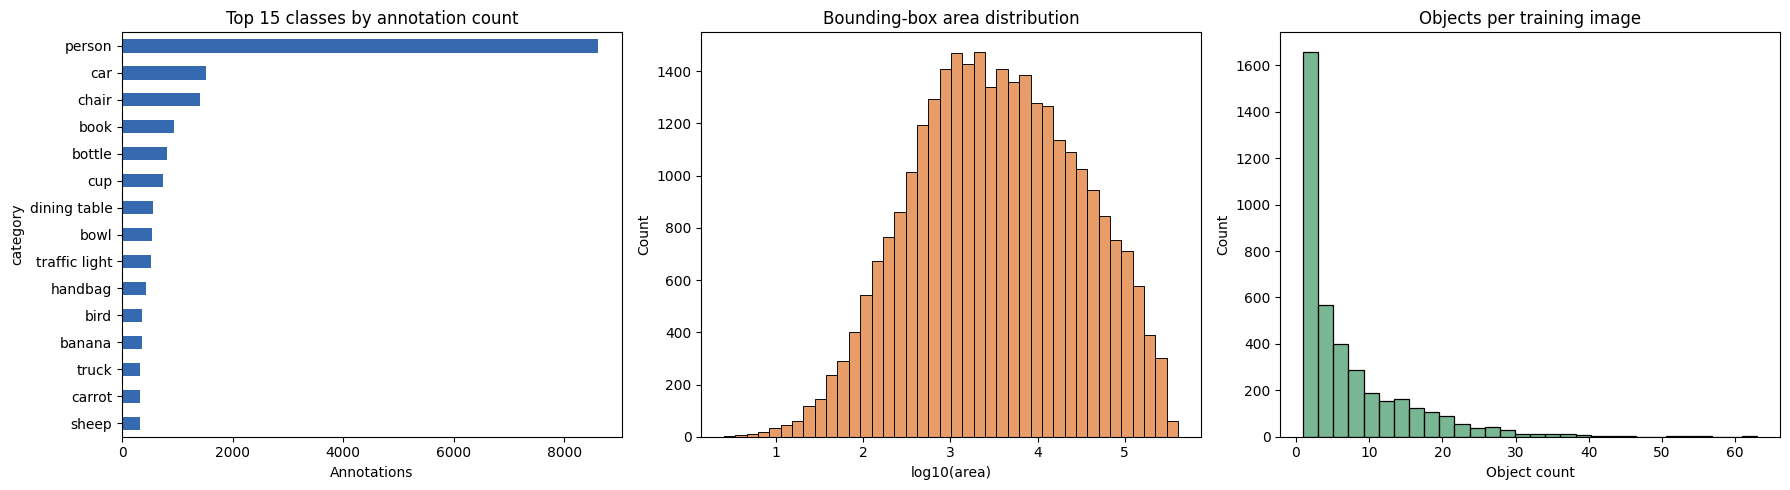

In [6]:
records = []
for ann in coco.dataset["annotations"]:
    if ann["image_id"] in train_id_set:
        x, y, w, h = ann["bbox"]
        records.append({
            "image_id": ann["image_id"], "category": cat_id_to_name[ann["category_id"]],
            "width": w, "height": h, "area": w*h, "iscrowd": ann.get("iscrowd", 0)
        })
eda = pd.DataFrame(records)
display(eda.describe(include="all").T)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
eda["category"].value_counts().head(15).sort_values().plot.barh(ax=axes[0], color="#3569b0")
axes[0].set_title("Top 15 classes by annotation count"); axes[0].set_xlabel("Annotations")
sns.histplot(np.log10(eda["area"].clip(lower=1)), bins=40, ax=axes[1], color="#e17c35")
axes[1].set_title("Bounding-box area distribution"); axes[1].set_xlabel("log10(area)")
objects_per_image = eda.groupby("image_id").size()
sns.histplot(objects_per_image, bins=30, ax=axes[2], color="#4c9f70")
axes[2].set_title("Objects per training image"); axes[2].set_xlabel("Object count")
plt.tight_layout(); plt.savefig(FIG_DIR / "eda_summary.png", dpi=200); plt.show()

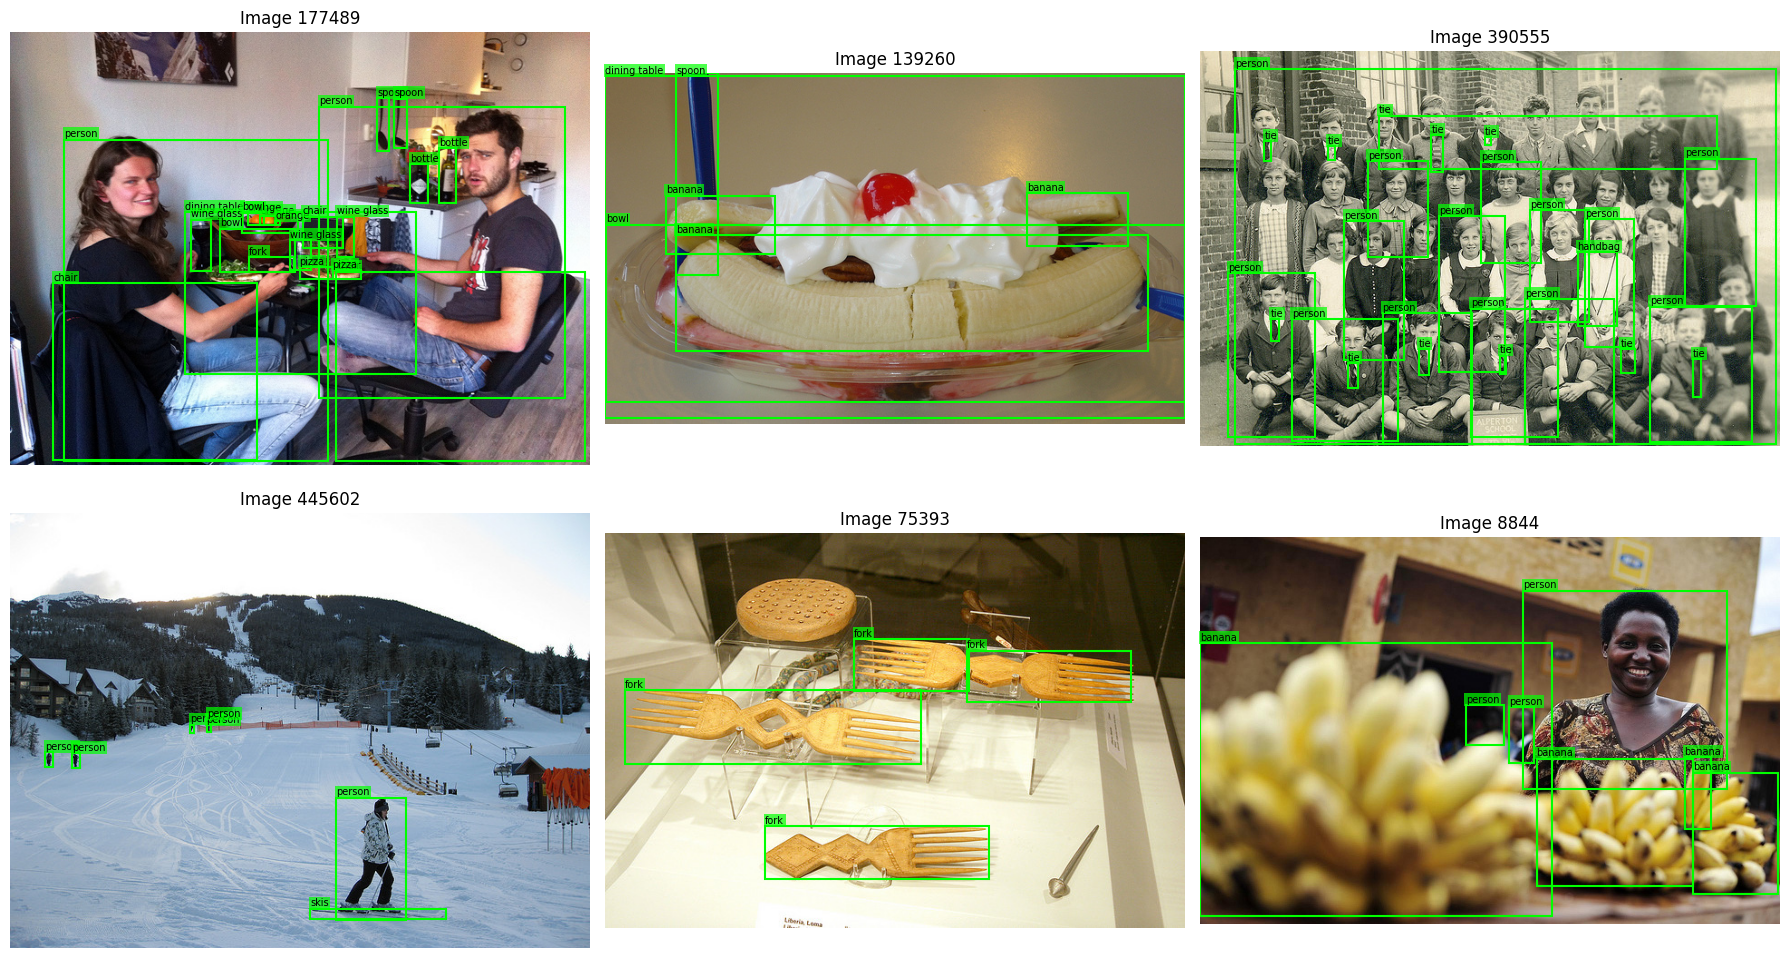

In [7]:
def show_raw_samples(image_ids, columns=3):
    rows = math.ceil(len(image_ids) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(6*columns, 5*rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, image_id in zip(axes, image_ids):
        info = coco.loadImgs(image_id)[0]
        image = np.array(Image.open(IMAGE_DIR / info["file_name"]).convert("RGB"))
        ax.imshow(image)
        for ann in coco.loadAnns(coco.getAnnIds(imgIds=[image_id], iscrowd=None)):
            x, y, w, h = ann["bbox"]
            ax.add_patch(plt.Rectangle((x,y), w,h, fill=False, color="lime", linewidth=1.5))
            ax.text(x, max(0,y-3), cat_id_to_name[ann["category_id"]], color="black", fontsize=7,
                    bbox=dict(facecolor="lime", alpha=.7, pad=1, edgecolor="none"))
        ax.set_title(f"Image {image_id}"); ax.axis("off")
    for ax in axes[len(image_ids):]: ax.axis("off")
    plt.tight_layout(); plt.savefig(FIG_DIR / "raw_samples.png", dpi=180); plt.show()

show_raw_samples(train_ids[:6])

### EDA interpretation

COCO is strongly imbalanced: common everyday categories occur much more frequently than rare categories. Bounding-box sizes also span several orders of magnitude, motivating multi-scale FPN features. Images commonly contain several objects, so object detection requires both localisation and classification rather than image-level classification alone.

## 4. Data preprocessing and augmentation

In [8]:
def build_transforms(training):
    transforms = []
    if training:
        transforms += [A.HorizontalFlip(p=0.5), A.RandomBrightnessContrast(p=0.2)]
    transforms += [
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ]
    return A.Compose(transforms, bbox_params=A.BboxParams(
        format="coco", label_fields=["labels"], min_visibility=0.1 if training else 0.0
    ))

class CocoYoloDataset(Dataset):
    def __init__(self, image_dir, annotation_file, image_ids, transforms):
        self.image_dir = Path(image_dir)
        self.coco = COCO(str(annotation_file))
        self.ids = list(image_ids)
        self.transforms = transforms

    def __len__(self): return len(self.ids)

    def __getitem__(self, index):
        image_id = self.ids[index]
        info = self.coco.loadImgs(image_id)[0]
        image = np.array(Image.open(self.image_dir / info["file_name"]).convert("RGB"))
        boxes, labels = [], []
        for ann in self.coco.loadAnns(self.coco.getAnnIds(imgIds=[image_id], iscrowd=False)):
            x, y, w, h = ann["bbox"]
            if w > 1 and h > 1:
                boxes.append([x,y,w,h]); labels.append(cat_id_to_label[ann["category_id"]])
        result = self.transforms(image=image, bboxes=boxes, labels=labels)
        boxes_xyxy = [[x,y,x+w,y+h] for x,y,w,h in result["bboxes"]]
        target = {
            "boxes": torch.tensor(boxes_xyxy, dtype=torch.float32).reshape(-1,4),
            "labels": torch.tensor(result["labels"], dtype=torch.long),
            "image_id": torch.tensor(image_id),
            "orig_size": torch.tensor([info["height"], info["width"]]),
        }
        return result["image"], target

def collate_fn(batch): return tuple(zip(*batch))

train_dataset = CocoYoloDataset(IMAGE_DIR, ANN_FILE, train_ids, build_transforms(True))
test_dataset = CocoYoloDataset(IMAGE_DIR, ANN_FILE, test_ids, build_transforms(False))
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                          pin_memory=torch.cuda.is_available(), collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                         pin_memory=torch.cuda.is_available(), collate_fn=collate_fn)
print("Train batches:", len(train_loader), "| Test batches:", len(test_loader))

loading annotations into memory...


Done (t=0.62s)
creating index...
index created!
loading annotations into memory...


Done (t=0.33s)
creating index...
index created!
Train batches: 4000 | Test batches: 1000


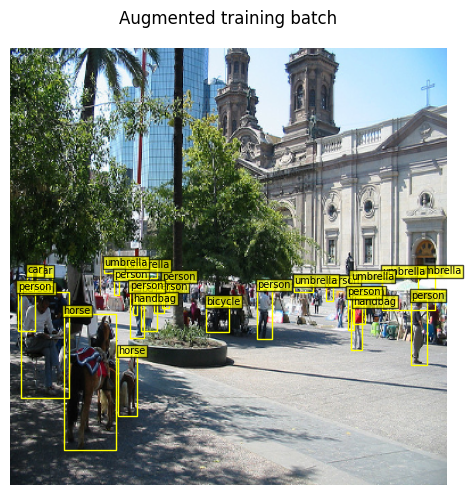

In [9]:
MEAN = np.array([0.485,0.456,0.406]); STD = np.array([0.229,0.224,0.225])
def denormalise(tensor):
    image = tensor.permute(1,2,0).cpu().numpy() * STD + MEAN
    return np.clip(image, 0, 1)

images, targets = next(iter(train_loader))
fig, axes = plt.subplots(1, min(3,len(images)), figsize=(16,5)); axes=np.atleast_1d(axes)
for ax, image, target in zip(axes, images, targets):
    ax.imshow(denormalise(image))
    for box, label in zip(target["boxes"], target["labels"]):
        x1,y1,x2,y2=box.tolist(); ax.add_patch(plt.Rectangle((x1,y1),x2-x1,y2-y1,fill=False,color="yellow"))
        ax.text(x1,y1,label_to_name[int(label)],fontsize=7,bbox=dict(facecolor="yellow",alpha=.7,pad=1))
    ax.axis("off")
plt.suptitle("Augmented training batch"); plt.tight_layout(); plt.show()

## 5. Model architecture

The detector has three components:

1. **ResNet50 backbone:** extracts hierarchical features C2–C5. ImageNet-pretrained weights provide transferable low-level features.
2. **Feature Pyramid Network:** combines high-resolution spatial information with deep semantic features.
3. **YOLO-style head:** predicts one box, objectness score, and 80 class logits at each cell on P3, P4, and P5 (strides 8, 16, and 32).

This is an educational YOLO-style implementation rather than an exact reproduction of a published YOLO version.

In [10]:
class ResNet50Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        net = resnet50(weights=ResNet50_Weights.DEFAULT)
        self.stem = nn.Sequential(net.conv1, net.bn1, net.relu, net.maxpool)
        self.layer1, self.layer2, self.layer3, self.layer4 = net.layer1, net.layer2, net.layer3, net.layer4
    def forward(self,x):
        x=self.stem(x); c2=self.layer1(x); c3=self.layer2(c2); c4=self.layer3(c3); c5=self.layer4(c4)
        return c2,c3,c4,c5

class FPN(nn.Module):
    def __init__(self, out_channels=256):
        super().__init__()
        self.lateral=nn.ModuleList([nn.Conv2d(c,out_channels,1) for c in (256,512,1024,2048)])
        self.output=nn.ModuleList([nn.Conv2d(out_channels,out_channels,3,padding=1) for _ in range(4)])
    def forward(self,features):
        c2,c3,c4,c5=features
        p5=self.lateral[3](c5)
        p4=self.lateral[2](c4)+F.interpolate(p5,size=c4.shape[-2:],mode="nearest")
        p3=self.lateral[1](c3)+F.interpolate(p4,size=c3.shape[-2:],mode="nearest")
        p2=self.lateral[0](c2)+F.interpolate(p3,size=c2.shape[-2:],mode="nearest")
        return tuple(layer(p) for layer,p in zip(self.output,(p2,p3,p4,p5)))

class DetectionHead(nn.Module):
    def __init__(self, channels=256, classes=80):
        super().__init__(); self.heads=nn.ModuleList()
        for _ in range(3):
            self.heads.append(nn.Sequential(nn.Conv2d(channels,channels,3,padding=1),nn.GroupNorm(32,channels),
                                            nn.SiLU(),nn.Conv2d(channels,5+classes,1)))
    def forward(self,pyramid): return [head(x) for head,x in zip(self.heads,pyramid[1:])]

class ResNet50FPNYolo(nn.Module):
    def __init__(self):
        super().__init__(); self.backbone=ResNet50Backbone(); self.fpn=FPN(); self.head=DetectionHead(classes=NUM_CLASSES)
        for parameter in self.backbone.parameters(): parameter.requires_grad=False
    def forward(self,x): return self.head(self.fpn(self.backbone(x)))

model=ResNet50FPNYolo().to(DEVICE)
with torch.no_grad(): sample_outputs=model(torch.randn(1,3,IMG_SIZE,IMG_SIZE,device=DEVICE))
print([tuple(x.shape) for x in sample_outputs])
print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

C:\Users\Vinh\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\module.py:1370: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return t.to(


[(1, 85, 48, 48), (1, 85, 24, 24), (1, 85, 12, 12)]
Parameters: 28.69M


## 6. Target assignment and loss

In [11]:
STRIDES=(8,16,32)
def encode_targets(targets, predictions):
    grids=[p.shape[-2:] for p in predictions]; encoded=[]
    for level,(stride,(gh,gw)) in enumerate(zip(STRIDES,grids)):
        batch=[]
        for target in targets:
            obj=torch.zeros((gh,gw),device=DEVICE); box_t=torch.zeros((4,gh,gw),device=DEVICE)
            cls_t=torch.zeros((gh,gw),dtype=torch.long,device=DEVICE); occupied=torch.full((gh,gw),float("inf"),device=DEVICE)
            for box,label in zip(target["boxes"],target["labels"]):
                x1,y1,x2,y2=box; w=(x2-x1).clamp(min=1); h=(y2-y1).clamp(min=1); size=torch.sqrt(w*h)
                assigned=0 if size<=64 else (1 if size<=160 else 2)
                if assigned!=level: continue
                cx=(x1+x2)/2; cy=(y1+y2)/2
                gx=int(torch.clamp(torch.floor(cx/stride),0,gw-1)); gy=int(torch.clamp(torch.floor(cy/stride),0,gh-1))
                if w*h < occupied[gy,gx]:
                    occupied[gy,gx]=w*h; obj[gy,gx]=1
                    box_t[:,gy,gx]=torch.stack((cx/stride-gx,cy/stride-gy,torch.log(w/stride),torch.log(h/stride)))
                    cls_t[gy,gx]=label
            batch.append((obj,box_t,cls_t))
        encoded.append(batch)
    return encoded

def focal_bce(logits, targets, alpha=.25, gamma=2.0):
    bce=F.binary_cross_entropy_with_logits(logits,targets,reduction="none")
    prob=torch.sigmoid(logits); pt=prob*targets+(1-prob)*(1-targets)
    alpha_t=alpha*targets+(1-alpha)*(1-targets)
    return (alpha_t*(1-pt).pow(gamma)*bce).mean()

def detection_loss(predictions,targets):
    encoded=encode_targets(targets,predictions)
    losses={"objectness":predictions[0].new_tensor(0.),"box":predictions[0].new_tensor(0.),"class":predictions[0].new_tensor(0.)}
    positives=0
    for pred,batch_targets in zip(predictions,encoded):
        for b,(obj_t,box_t,cls_t) in enumerate(batch_targets):
            pos=obj_t.bool(); losses["objectness"] += focal_bce(pred[b,4],obj_t)
            if pos.any():
                positives += int(pos.sum())
                losses["box"] += F.smooth_l1_loss(pred[b,:4][:,pos],box_t[:,pos])
                losses["class"] += F.cross_entropy(pred[b,5:][:,pos].T,cls_t[pos])
    normaliser=max(1,len(targets)*len(predictions))
    losses={k:v/normaliser for k,v in losses.items()}
    total=losses["objectness"]+5*losses["box"]+losses["class"]
    return total,{k:float(v.detach()) for k,v in losses.items()},positives

## 7. Training and validation

In [12]:
optimizer=torch.optim.AdamW((p for p in model.parameters() if p.requires_grad),lr=LR,weight_decay=WEIGHT_DECAY)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS)
scaler=torch.amp.GradScaler("cuda",enabled=DEVICE.type=="cuda")

def run_epoch(loader,training):
    model.train(training); totals=defaultdict(float); batches=0
    for images,targets in loader:
        images=torch.stack(images).to(DEVICE,non_blocking=True)
        targets=[{k:(v.to(DEVICE) if torch.is_tensor(v) else v) for k,v in t.items()} for t in targets]
        if training: optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training), torch.amp.autocast("cuda",enabled=DEVICE.type=="cuda"):
            loss,parts,positives=detection_loss(model(images),targets)
            if training:
                scaler.scale(loss).backward(); scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(),5.0)
                scaler.step(optimizer); scaler.update()
        totals["loss"]+=float(loss.detach()); totals["positives"]+=positives
        for k,v in parts.items(): totals[k]+=v
        batches+=1
    return {k:v/max(1,batches) for k,v in totals.items()}

history=[]; best_val=float("inf"); start=time.time()
for epoch in range(1,EPOCHS+1):
    train_metrics=run_epoch(train_loader,True)
    val_metrics=run_epoch(test_loader,False)
    scheduler.step()
    row={"epoch":epoch,"lr":scheduler.get_last_lr()[0],**{f"train_{k}":v for k,v in train_metrics.items()},
         **{f"val_{k}":v for k,v in val_metrics.items()}}
    history.append(row); print(f"Epoch {epoch:02d}/{EPOCHS} | train {row['train_loss']:.4f} | val {row['val_loss']:.4f}")
    if row["val_loss"]<best_val:
        best_val=row["val_loss"]; torch.save({"model":model.state_dict(),"config":CONFIG,"epoch":epoch},MODEL_DIR/"best_model.pt")

history=pd.DataFrame(history); history.to_csv(OUTPUT_DIR/"training_history.csv",index=False)
print(f"Training time: {(time.time()-start)/60:.1f} minutes | Best validation loss: {best_val:.4f}")

Epoch 01/3 | train 2.3228 | val 2.0437


Epoch 02/3 | train 1.8011 | val 1.7548


Epoch 03/3 | train 1.4397 | val 1.8070
Training time: 9.9 minutes | Best validation loss: 1.7548


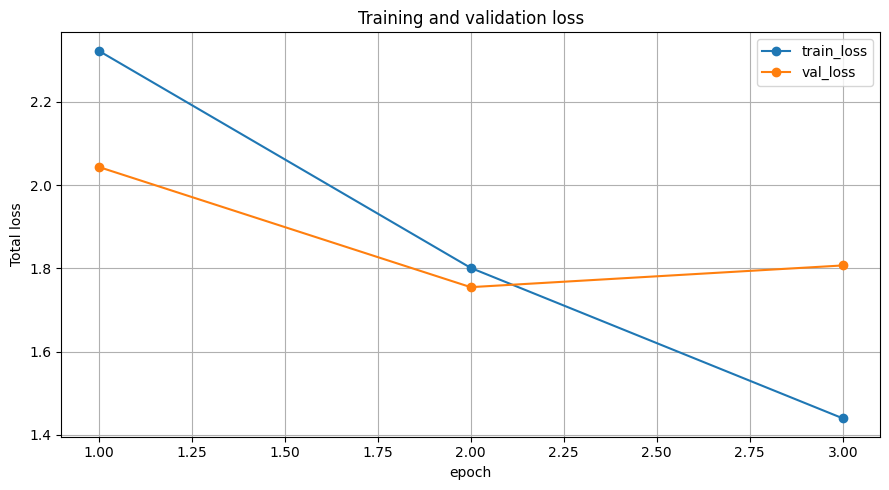

Loaded best epoch: 2


In [13]:
ax=history.plot(x="epoch",y=["train_loss","val_loss"],marker="o",figsize=(9,5),grid=True)
ax.set_title("Training and validation loss"); ax.set_ylabel("Total loss")
plt.tight_layout(); plt.savefig(FIG_DIR/"loss_curves.png",dpi=200); plt.show()

checkpoint=torch.load(MODEL_DIR/"best_model.pt",map_location=DEVICE,weights_only=False)
model.load_state_dict(checkpoint["model"]); print("Loaded best epoch:",checkpoint["epoch"])

## 8. Prediction decoding and non-maximum suppression

In [14]:
def decode_image(predictions,threshold=CONF_THRESHOLD):
    all_boxes=[]; all_scores=[]; all_labels=[]
    for prediction,stride in zip(predictions,STRIDES):
        p=prediction[0]; _,h,w=p.shape; obj=torch.sigmoid(p[4]); class_prob=torch.softmax(p[5:],dim=0)
        yy,xx=torch.meshgrid(torch.arange(h,device=DEVICE),torch.arange(w,device=DEVICE),indexing="ij")
        cx=(xx+torch.sigmoid(p[0]))*stride; cy=(yy+torch.sigmoid(p[1]))*stride
        bw=torch.exp(p[2].clamp(-4,4))*stride; bh=torch.exp(p[3].clamp(-4,4))*stride
        class_score,label=class_prob.max(dim=0); score=obj*class_score; keep=score>=threshold
        if keep.any():
            all_boxes.append(torch.stack((cx-bw/2,cy-bh/2,cx+bw/2,cy+bh/2),dim=-1)[keep])
            all_scores.append(score[keep]); all_labels.append(label[keep])
    if not all_boxes:
        return torch.empty((0,4),device=DEVICE),torch.empty(0,device=DEVICE),torch.empty(0,dtype=torch.long,device=DEVICE)
    boxes=torch.cat(all_boxes); scores=torch.cat(all_scores); labels=torch.cat(all_labels)
    boxes[:,0::2].clamp_(0,IMG_SIZE); boxes[:,1::2].clamp_(0,IMG_SIZE)
    keep=batched_nms(boxes,scores,labels,NMS_IOU_THRESHOLD)[:MAX_DETECTIONS]
    return boxes[keep],scores[keep],labels[keep]

def predict_tensor(image,threshold=CONF_THRESHOLD):
    model.eval()
    with torch.no_grad(): predictions=model(image.unsqueeze(0).to(DEVICE))
    return tuple(x.cpu() for x in decode_image(predictions,threshold))

## 9. Official COCO evaluation

In [15]:
def create_coco_predictions(dataset):
    results=[]; model.eval()
    for index in range(len(dataset)):
        image,target=dataset[index]; boxes,scores,labels=predict_tensor(image,CONF_THRESHOLD)
        original_h,original_w=target["orig_size"].tolist(); sx=original_w/IMG_SIZE; sy=original_h/IMG_SIZE
        for box,score,label in zip(boxes,scores,labels):
            x1,y1,x2,y2=box.tolist(); x1*=sx; x2*=sx; y1*=sy; y2*=sy
            results.append({"image_id":int(target["image_id"]),"category_id":label_to_cat_id[int(label)],
                            "bbox":[x1,y1,max(0,x2-x1),max(0,y2-y1)],"score":float(score)})
        if (index+1)%100==0: print(f"Predicted {index+1}/{len(dataset)} images")
    return results

coco_predictions=create_coco_predictions(test_dataset)
prediction_file=PRED_DIR/"coco_predictions.json"
prediction_file.write_text(json.dumps(coco_predictions),encoding="utf-8")
print("Predictions:",len(coco_predictions))
assert coco_predictions, "No predictions were produced. Check training or lower CONF_THRESHOLD."

coco_dt=coco.loadRes(str(prediction_file)); evaluator=COCOeval(coco,coco_dt,"bbox")
evaluator.params.imgIds=test_ids; evaluator.evaluate(); evaluator.accumulate(); evaluator.summarize()
metric_names=["mAP_50_95","AP50","AP75","AP_small","AP_medium","AP_large"]
metrics=dict(zip(metric_names,map(float,evaluator.stats[:6])))
pd.DataFrame(metrics.items(),columns=["Metric","Value"]).to_csv(OUTPUT_DIR/"coco_metrics.csv",index=False)
display(pd.DataFrame(metrics.items(),columns=["Metric","Value"]))

Predicted 100/1000 images


Predicted 200/1000 images


Predicted 300/1000 images


Predicted 400/1000 images


Predicted 500/1000 images


...

Predictions: 81968
Loading and preparing results...


DONE (t=0.57s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*


DONE (t=3.16s).
Accumulating evaluation results...


DONE (t=0.61s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.010
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.006
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.007
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.008
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.014
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.015
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.004
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.019
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.022


,Metric,Value
0,mAP_50_95,0.002733
1,AP50,0.009906
2,AP75,0.000573
3,AP_small,0.000408
4,AP_medium,0.005560
5,AP_large,0.006700


In [16]:
precision=evaluator.eval["precision"]
rows=[]
for k,category in enumerate(categories):
    values=precision[:,:,k,0,2]; values=values[values>-1]
    rows.append({"class":category["name"],"AP":float(values.mean()) if values.size else np.nan})
per_class_ap=pd.DataFrame(rows).sort_values("AP",ascending=False)
per_class_ap.to_csv(OUTPUT_DIR/"per_class_ap.csv",index=False)
display(per_class_ap.head(10)); display(per_class_ap.tail(10))

,class,AP
23,giraffe,0.043181
49,orange,0.019802
62,tv,0.015199
41,cup,0.013580
66,keyboard,0.009598
38,tennis racket,0.009552
74,clock,0.008792
61,toilet,0.008492
32,sports ball,0.008087
53,pizza,0.006746


,class,AP
12,parking meter,0.0
42,fork,0.0
43,knife,0.0
44,spoon,0.0
45,bowl,0.0
46,banana,0.0
11,stop sign,0.0
19,cow,0.0
79,toothbrush,0.0
70,toaster,NaN


## 10. Qualitative results and failure analysis

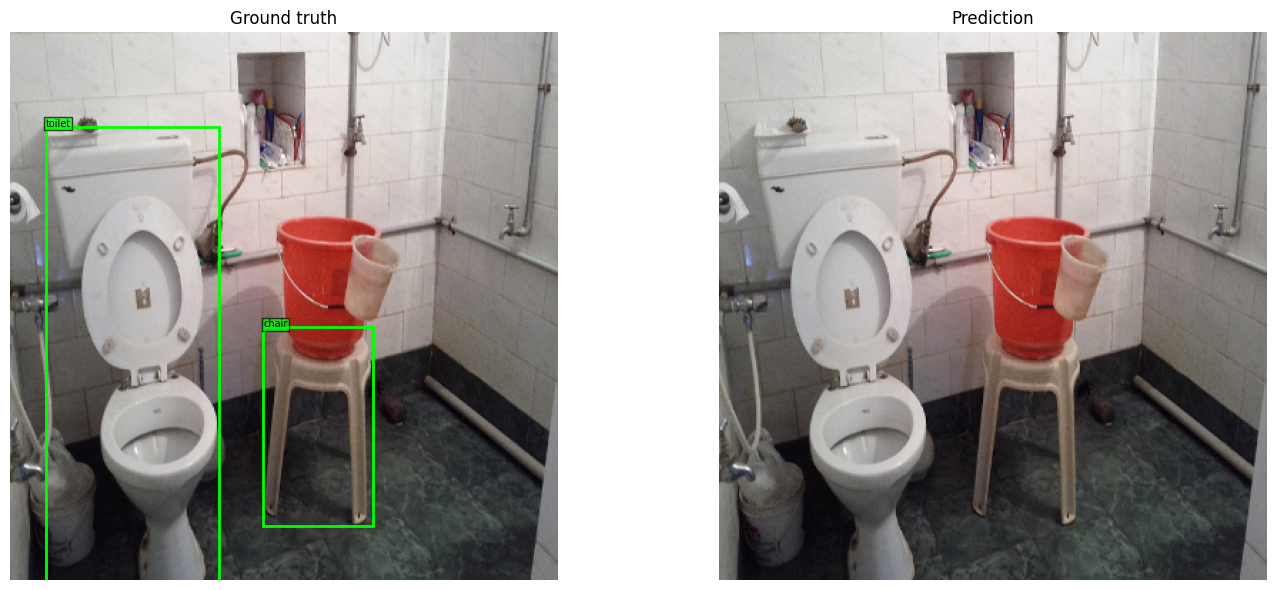

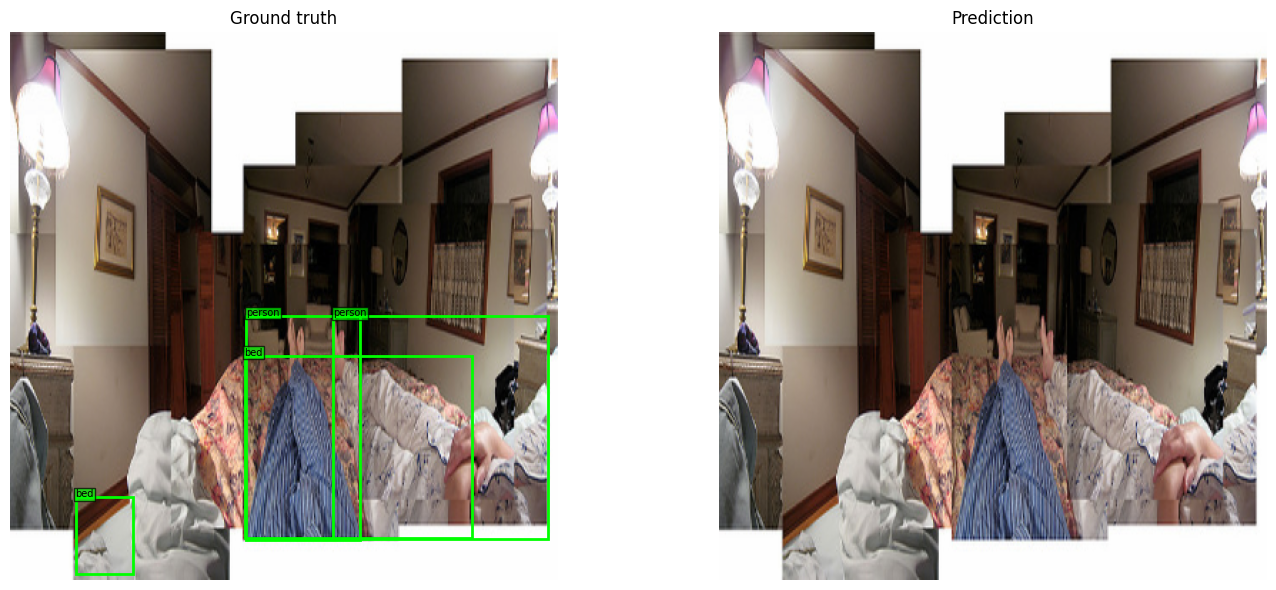

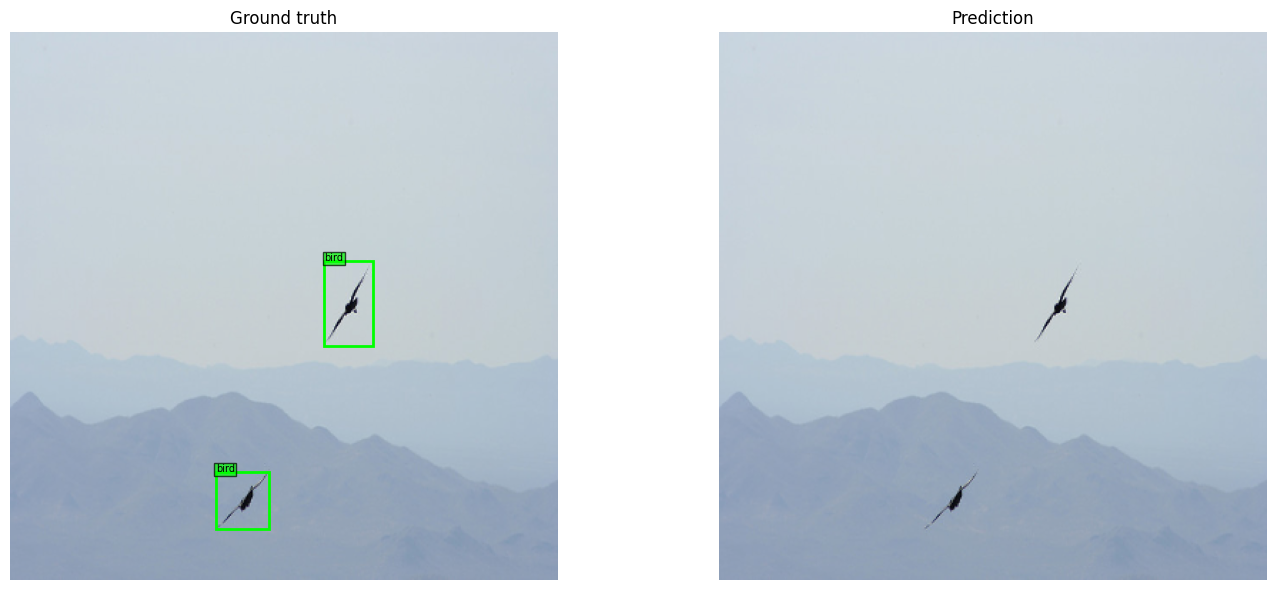

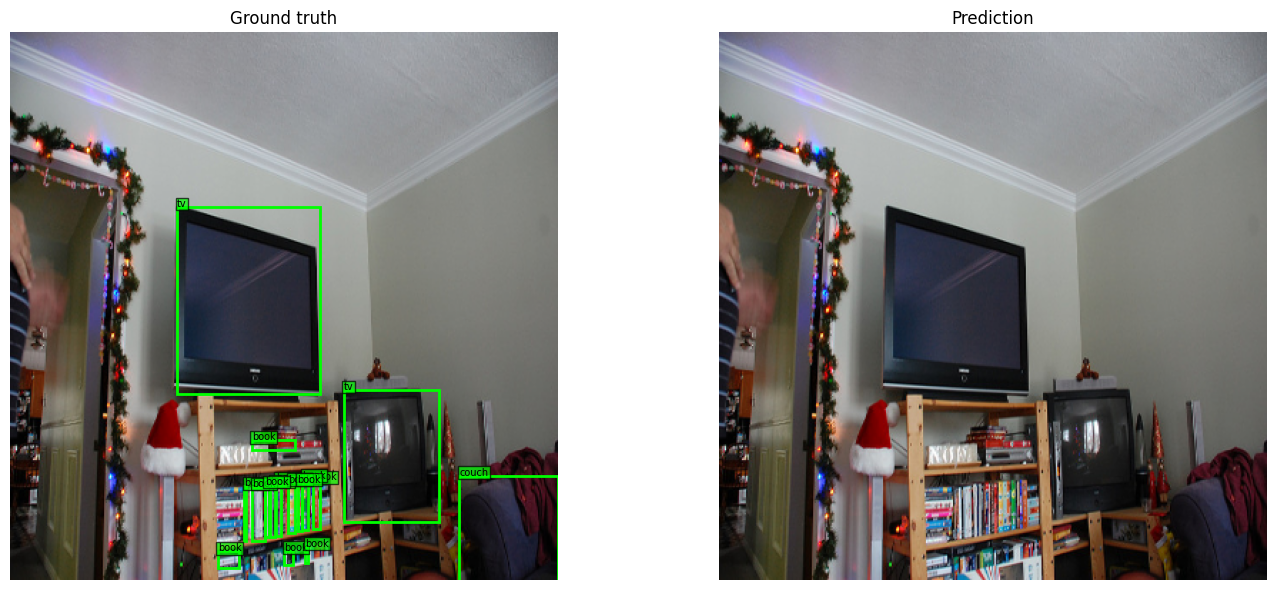

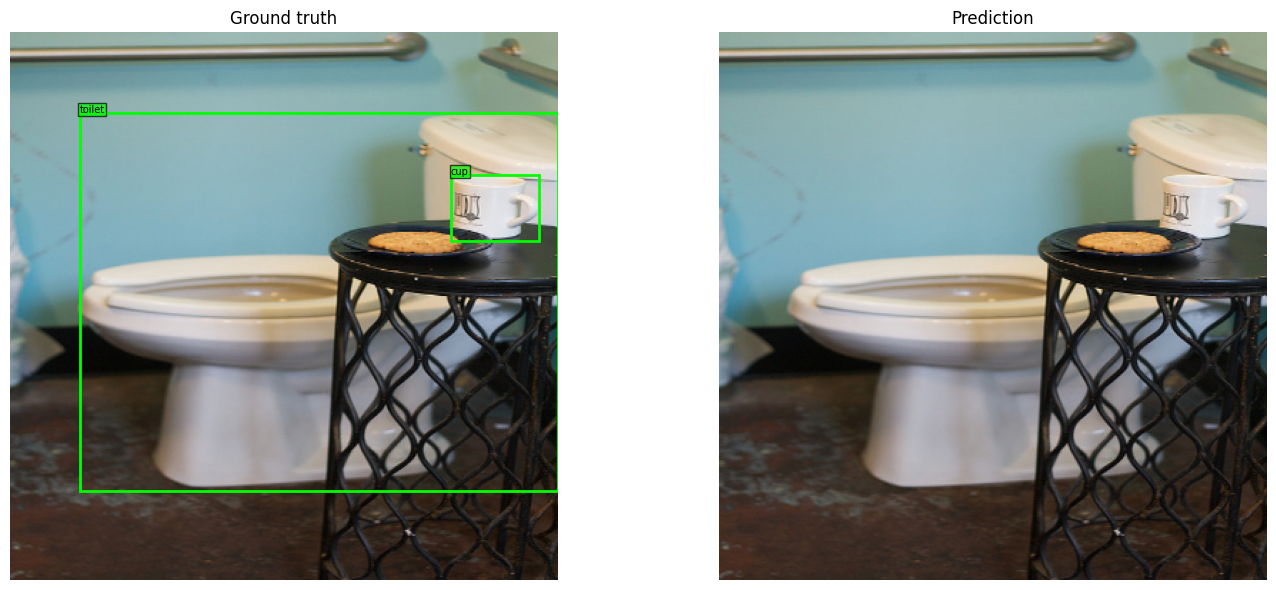

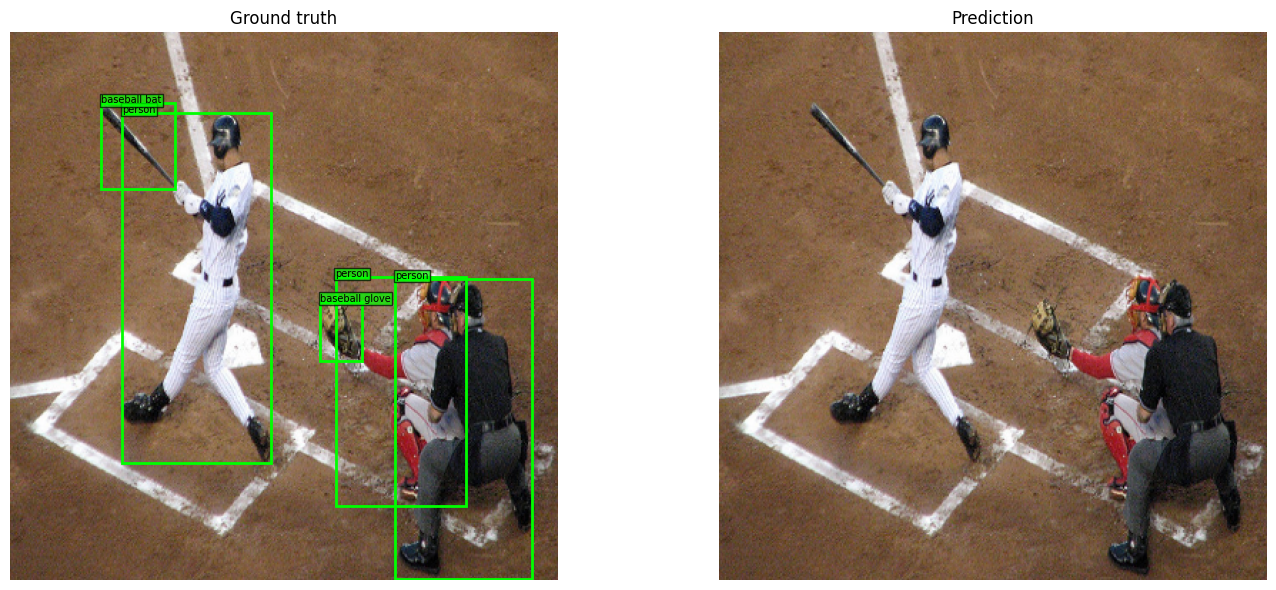

In [17]:
def visualise_comparison(index,threshold=VIS_THRESHOLD):
    image,target=test_dataset[index]; boxes,scores,labels=predict_tensor(image,threshold); shown=denormalise(image)
    fig,axes=plt.subplots(1,2,figsize=(15,6))
    for ax,title in zip(axes,("Ground truth","Prediction")): ax.imshow(shown); ax.set_title(title); ax.axis("off")
    for box,label in zip(target["boxes"],target["labels"]):
        x1,y1,x2,y2=box.tolist(); axes[0].add_patch(plt.Rectangle((x1,y1),x2-x1,y2-y1,fill=False,color="lime",linewidth=2))
        axes[0].text(x1,y1,label_to_name[int(label)],fontsize=7,bbox=dict(facecolor="lime",alpha=.7,pad=1))
    for box,score,label in zip(boxes,scores,labels):
        x1,y1,x2,y2=box.tolist(); axes[1].add_patch(plt.Rectangle((x1,y1),x2-x1,y2-y1,fill=False,color="orange",linewidth=2))
        axes[1].text(x1,y1,f"{label_to_name[int(label)]} {score:.2f}",fontsize=7,bbox=dict(facecolor="orange",alpha=.7,pad=1))
    plt.tight_layout(); return fig

for i in range(min(6,len(test_dataset))):
    fig=visualise_comparison(i); fig.savefig(FIG_DIR/f"comparison_{i}.png",dpi=180); plt.show()

### Result interpretation prompts

After executing the experiment, answer these points using the generated figures and tables:

- Which classes obtain the highest and lowest AP, and how does this relate to class frequency?
- Are small objects harder than medium and large objects?
- Identify examples of false positives, false negatives, localisation errors, and class confusion.
- Does validation loss improve consistently, or is there evidence of overfitting?
- How do the limited training set and one-box-per-cell design constrain performance?

In [18]:
summary = f'''EXPERIMENT SUMMARY
Best epoch: {checkpoint['epoch']}
Best validation loss: {best_val:.4f}
mAP@[0.50:0.95]: {metrics['mAP_50_95']:.4f}
AP50: {metrics['AP50']:.4f}
AP75: {metrics['AP75']:.4f}
AP small/medium/large: {metrics['AP_small']:.4f} / {metrics['AP_medium']:.4f} / {metrics['AP_large']:.4f}
Predictions: {len(coco_predictions)}
'''
print(summary); (OUTPUT_DIR/"experiment_summary.txt").write_text(summary,encoding="utf-8")

EXPERIMENT SUMMARY
Best epoch: 2
Best validation loss: 1.7548
mAP@[0.50:0.95]: 0.0027
AP50: 0.0099
AP75: 0.0006
AP small/medium/large: 0.0004 / 0.0056 / 0.0067
Predictions: 81968



179

## 11. Conclusion

This coursework implements an end-to-end object detection pipeline using a ResNet50 backbone, an FPN, and a custom YOLO-style multi-scale head. The official COCO evaluator reports localisation and classification performance across IoU thresholds and object sizes. The final discussion should quote the generated metrics above and connect them to the EDA and qualitative failure cases.

### Limitations

- Only 4,000 images are used for training, far fewer than the full COCO training set.
- The educational head predicts one object per grid cell and does not use modern dynamic label assignment.
- The localisation objective is Smooth L1 rather than a modern IoU-family loss.
- Hyperparameter tuning and repeated runs are outside the available compute budget.

### Future work

- Train on the complete COCO train2017 split.
- Add multiple predictions per location and CIoU loss.
- Compare against RetinaNet or Faster R-CNN under the same split.
- Apply mixed precision, early stopping, and systematic hyperparameter search.

## References

1. Lin, T.-Y. et al. (2014). *Microsoft COCO: Common Objects in Context*. ECCV.
2. He, K. et al. (2016). *Deep Residual Learning for Image Recognition*. CVPR.
3. Lin, T.-Y. et al. (2017). *Feature Pyramid Networks for Object Detection*. CVPR.
4. Redmon, J. et al. (2016). *You Only Look Once: Unified, Real-Time Object Detection*. CVPR.
5. Lin, T.-Y. et al. (2017). *Focal Loss for Dense Object Detection*. ICCV.